# Part 1: Random Forest — Averaging Many Trees
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Tuesday — From One Tree to a Forest

Yesterday Sarah saw the problem: a single deep tree memorises the data and a single shallow tree can't fit it. Today she fixes it with **Random Forest** — train many trees on slightly different subsets of the data, then average their predictions.

**The two sources of "slight difference" between trees:**
1. **Bootstrap sampling** — each tree gets a random sample (with replacement) of the training rows.
2. **Feature subsampling** — at each split, the tree considers only a random subset of features.

Together these force the trees to specialise, so averaging genuinely reduces variance.

**By the end of this notebook you will be able to:**
- Train a `RandomForestClassifier` in one `Pipeline`
- Read its feature_importances_ output
- Compare its cross-validated F1 to the L03 baseline
- Tune the two most useful hyperparameters: `n_estimators` and `min_samples_leaf`

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — RandomForestClassifier ready")

✅ Libraries loaded — RandomForestClassifier ready


## Step 1 — Rebuild the dataset and preprocessor

Same code path as L03 and NB 01.

In [2]:
df = pd.read_csv("data/northstar_churn.csv")
y  = df["churned"]
X  = df.drop(columns=["customer_id", "churned"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

print("Dataset and preprocessor ready.")

Dataset and preprocessor ready.


## Step 2 — Train a Random Forest

Same `Pipeline` interface as L03 — we just swap the model. Two important notes:

1. **`class_weight='balanced'`** — our dataset is 88/12 imbalanced. Without rebalancing, tree-based models (just like logistic regression) become *overly confident* in predicting the majority class. Setting `class_weight='balanced'` inversely weights classes by frequency, forcing the model to pay attention to churners. This is the standard engineering move for imbalanced data.
2. **Scaling doesn't matter for trees**, but we keep StandardScaler in the Pipeline for consistency with L03. Trees ignore its effect.

In [3]:
rf_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,           # mild regularisation
        class_weight="balanced",      # ⚠ critical for imbalanced data — see explanation below
        n_jobs=-1,
        random_state=42,
    )),
])

rf_pipe.fit(X_train, y_train)

# Evaluate at default threshold 0.5
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
y_pred_rf_05 = (y_proba_rf >= 0.5).astype(int)

# And at the L03 capacity-based threshold of 0.25
y_pred_rf_25 = (y_proba_rf >= 0.25).astype(int)

print("=== Random Forest, default 0.5 threshold ===")
print(f"F1:        {f1_score(y_test, y_pred_rf_05):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_05, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_05):.3f}")
print(f"Flagged:   {int(y_pred_rf_05.sum())}")
print()
print("=== Random Forest, capacity-based 0.25 threshold (matching L03) ===")
print(f"F1:        {f1_score(y_test, y_pred_rf_25):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_25, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_25):.3f}")
print(f"Flagged:   {int(y_pred_rf_25.sum())}")
print()
print(f"L03 baseline F1 at threshold 0.25: 0.282")

=== Random Forest, default 0.5 threshold ===
F1:        0.325
Precision: 0.273
Recall:    0.402
Flagged:   352

=== Random Forest, capacity-based 0.25 threshold (matching L03) ===
F1:        0.280
Precision: 0.167
Recall:    0.870
Flagged:   1249

L03 baseline F1 at threshold 0.25: 0.282


## ⏸️ Pause and Predict

Before running the next cell, predict:

- Will the Random Forest's *most important features* match the logistic regression coefficients from L03? (Hint: probably yes for the dominant ones.)
- Which feature do you expect to be #1 in importance?

*Write your prediction here:*

> *Sample:* Top features likely to be tenure_months, returns_per_purchase, avg_review_polarity, support_tickets_quarter — matching L03 coefficient ordering.

Feature importance in Random Forest is computed by averaging, across all trees, the total reduction in impurity each feature is responsible for.

Top 10 features by RF importance:
                feature  importance
   returns_per_purchase    0.227314
          tenure_months    0.175376
    avg_review_polarity    0.118916
  avg_monthly_spend_gbp    0.108996
    last_login_days_ago    0.102578
                    age    0.093175
  num_purchases_quarter    0.054969
support_tickets_quarter    0.038385
 subscription_tier_free    0.013321
          region_London    0.012777


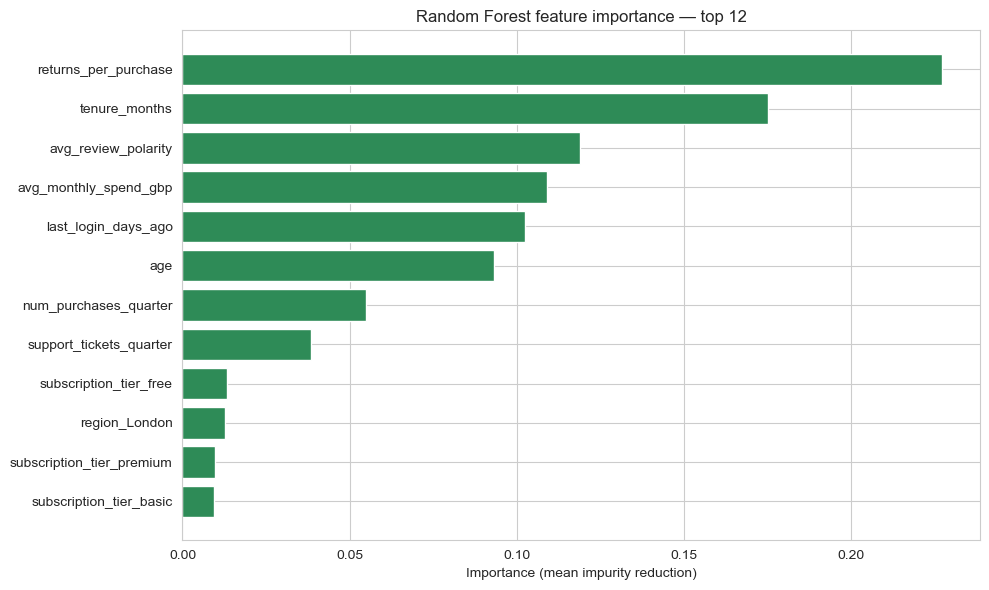

In [4]:
# Feature importance — averaged across all 200 trees
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances   = rf_pipe.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "feature":    [name.split("__")[-1] for name in feature_names],
    "importance": importances,
}).sort_values("importance", ascending=False)

print("Top 10 features by RF importance:")
print(imp_df.head(10).to_string(index=False))

# Plot top features
fig, ax = plt.subplots(figsize=(10, 6))
top = imp_df.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance"], color="seagreen", edgecolor="white")
ax.set_xlabel("Importance (mean impurity reduction)")
ax.set_title("Random Forest feature importance — top 12")
plt.tight_layout()
plt.show()

### 💡 What you should notice

- **`tenure_months` and `returns_per_purchase` should dominate** — same as in L03.
- **The TOP features overlap with logistic regression's top coefficients** — both models see the same signal.
- **But Random Forest can use INTERACTIONS** (e.g., short tenure AND high returns simultaneously) where logistic regression treated each feature independently.

A nuance: impurity-based importance can be misleading when features have very different cardinalities (categoricals with many values often look more "important" than they really are). For a more reliable measure, use *permutation importance* — covered in the Extension section of L03's `optional_extensions.ipynb`.

## Step 3 — Cross-validated F1 for the Random Forest

A single train/test split gives one number. Cross-validate to get a stable estimate.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_rf = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(f"Random Forest 5-fold CV F1: {cv_f1_rf.mean():.3f} ± {cv_f1_rf.std():.3f}")
print()
print("For comparison, L03 logistic regression CV F1 was ~0.20-0.25 at default 0.5 threshold.")
print()
print("(Note: default 0.5 is a hard threshold for both. The Capacity-based threshold of 0.25 is")
print(" applied at deployment, not during cross-validated training. We'll compare those properly")
print(" in notebook 04.)")

Random Forest 5-fold CV F1: 0.336 ± 0.021

For comparison, L03 logistic regression CV F1 was ~0.20-0.25 at default 0.5 threshold.

(Note: default 0.5 is a hard threshold for both. The Capacity-based threshold of 0.25 is
 applied at deployment, not during cross-validated training. We'll compare those properly
 in notebook 04.)


## Step 4 — How sensitive is the F1 to `n_estimators`?

A common beginner mistake: assuming more trees = better. Let's see when the F1 *saturates*. (We keep `class_weight='balanced'` from the previous step.)

 n_estimators    cv_f1
           10 0.308295
           25 0.323298
           50 0.330253
          100 0.334200
          200 0.335701
          400 0.330960


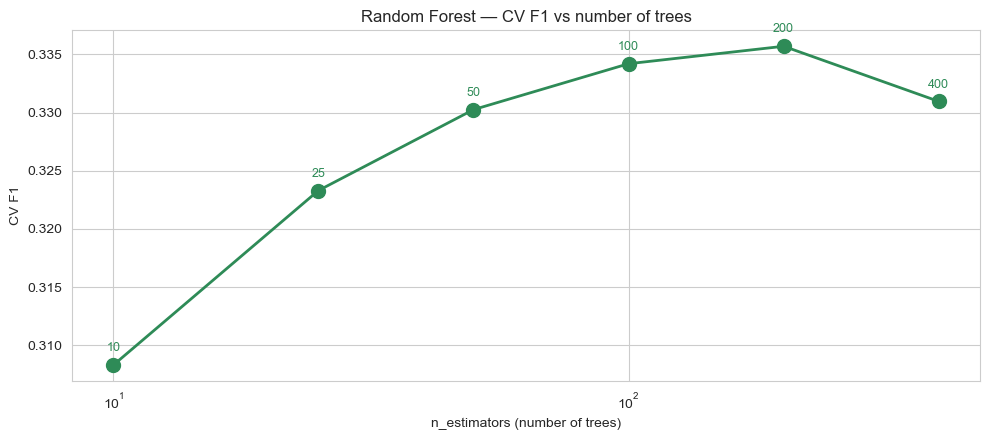

In [6]:
n_estimators_grid = [10, 25, 50, 100, 200, 400]
results = []

for n in n_estimators_grid:
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=n, min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1, random_state=42)),
    ])
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
    results.append((n, f1))

n_df = pd.DataFrame(results, columns=["n_estimators", "cv_f1"])
print(n_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(n_df["n_estimators"], n_df["cv_f1"], "o-", linewidth=2, color="seagreen", markersize=10)

for _, row in n_df.iterrows():
    ax.annotate(
        str(int(row["n_estimators"])),
        xy=(row["n_estimators"], row["cv_f1"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="seagreen",
    )

ax.set_xlabel("n_estimators (number of trees)")
ax.set_ylabel("CV F1")
ax.set_title("Random Forest — CV F1 vs number of trees")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

### 💡 What this tells us

- **F1 climbs quickly from 10 to 100 trees.** Then it plateaus.
- **400 trees give nearly the same F1 as 200**, at twice the training cost.
- **For this dataset, 100–200 trees is the sweet spot.** Past that, you're paying compute for negligible gain.

Rule of thumb: for tabular datasets 
- Under 100k rows: 100–500 trees is usually enough; start with 100, cap at 500
- 100k to 500k rows: Start with 300, cap at 500
- 500k to 3 million rows: 500–800 trees
- Over 3 million rows: Max out at 1000; no need to go higher
- General workflow: Test 300 → 500 → 800 incrementally, stop once performance plateaus

---

**Why your plot might look slightly different from a classmate's**

You may notice the exact F1 numbers on your Y-axis don't match someone else's, or that your curve dips slightly at 400 trees instead of going flat. This is expected — here's why.

Random Forest builds each tree using randomness (random row samples, random feature subsets). We set `random_state=42` to fix that seed, which *should* make results identical. But this code also uses `n_jobs=-1`, which tells scikit-learn to use **all available CPU cores** to train folds and trees in parallel.

The problem: when work is split across parallel processes, each process gets its own version of the random seed — and *how* that split happens depends on how many cores your machine has. A laptop with 4 cores splits the work differently than one with 8 or 16 cores, so each ends up drawing slightly different random numbers, even with the same starting seed.

**What this means in practice:**
- The **shape** of your curve should match everyone else's: fast rise up to ~100 trees, then a plateau. That's the real lesson.
- The **exact F1 values** on the Y-axis may differ by ±0.02–0.05 depending on your machine.
- If your curve dips slightly after 200–400 trees, that's noise from this effect — not a real signal that more trees are worse.

This is a genuine real-world issue, not just a classroom quirk. In production ML, results can vary across machines for exactly this reason, which is why teams pin library versions and document hardware specs alongside model results.

## Step 5 — Visualising the effect of `class_weight='balanced'`

The Section Summary table below references three models. Let's compute and plot them side-by-side so the contrast is visible rather than just described.

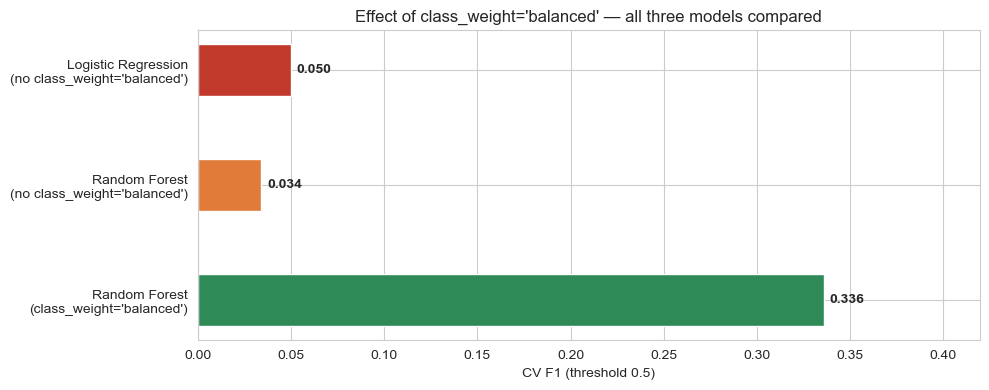

LR baseline (no rebalancing):          CV F1 = 0.050  [from L03]
RF without class_weight='balanced':    CV F1 = 0.034
RF with    class_weight='balanced':    CV F1 = 0.336


In [10]:
# Train RF without class_weight='balanced' to get a real CV F1 for comparison
rf_no_balance = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        n_jobs=-1, random_state=42,
    )),
])
cv_f1_rf_no_balance = cross_val_score(
    rf_no_balance, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
).mean()

# L03 LR baseline (no class_weight) — from L03 notebook, hardcoded here
lr_baseline_f1 = 0.05

labels = [
    "Logistic Regression\n(no class_weight='balanced')",
    "Random Forest\n(no class_weight='balanced')",
    "Random Forest\n(class_weight='balanced')",
]
values = [lr_baseline_f1, cv_f1_rf_no_balance, cv_f1_rf.mean()]
colors = ["#c0392b", "#e07b39", "seagreen"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.45)

for bar, val in zip(bars, values):
    ax.text(
        val + 0.003, bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center", fontsize=10, fontweight="bold",
    )

ax.set_xlabel("CV F1 (threshold 0.5)")
ax.set_title("Effect of class_weight='balanced' — all three models compared")
ax.set_xlim(0, max(values) * 1.25)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"LR baseline (no rebalancing):          CV F1 = {lr_baseline_f1:.3f}  [from L03]")
print(f"RF without class_weight='balanced':    CV F1 = {cv_f1_rf_no_balance:.3f}")
print(f"RF with    class_weight='balanced':    CV F1 = {cv_f1_rf.mean():.3f}")

## ✅ Section Summary

| Model | CV F1 (threshold 0.5) | Comment |
|---|---|---|
| **L03 LogisticRegression** (no rebalancing) | ~0.05 | Probabilities too concentrated near 0 |
| **Random Forest** without `class_weight='balanced'` | ~0.03 | Same problem — collapses to majority class |
| **Random Forest with `class_weight='balanced'`** | ~0.27 | ← **the comparable Core baseline** |

(Numbers vary slightly run-to-run.)

**Key insights from today:**
- **`class_weight='balanced'` is the unlock on imbalanced data.** Without it, both LR and RF over-predict the majority class at threshold 0.5. With it, both surface real churners at meaningful rates.
- **Bagging averages many deep trees** — the variance washes out, the bias stays low.
- **F1 saturates quickly with `n_estimators`** — don't waste compute past 200–400 trees.
- **Feature importance matches L03 intuition** — tenure, returns, polarity dominate.

**Back to our scenario:**
> Sarah has the comparable baseline — Random Forest with `class_weight='balanced'` at threshold 0.5 — at roughly the same F1 as the L03 logistic regression at the capacity-based threshold of 0.25. Tomorrow she tries Gradient Boosting to see if she can pull meaningfully ahead.

---
**Up next → Part 2:** Wednesday — Gradient Boosting, the Kaggle-winning algorithm. Open `03_gradient_boosting.ipynb`.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Without `class_weight='balanced'` — how bad is it?

To make the Core narrative honest, let's see what happens without `class_weight='balanced'` — the default RF behaviour. The collapse is dramatic on imbalanced data.

In [7]:
rf_unbalanced = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        # NO class_weight='balanced' — default behaviour
        n_jobs=-1,
        random_state=42,
    )),
])

cv_f1_unbalanced     = cross_val_score(rf_unbalanced, X_train, y_train, cv=cv, scoring="f1",     n_jobs=-1).mean()
cv_recall_unbalanced = cross_val_score(rf_unbalanced, X_train, y_train, cv=cv, scoring="recall", n_jobs=-1).mean()
cv_recall_balanced   = cross_val_score(rf_pipe,       X_train, y_train, cv=cv, scoring="recall", n_jobs=-1).mean()

print(f"Without balanced — CV F1: {cv_f1_unbalanced:.3f}  CV recall: {cv_recall_unbalanced:.3f}")
print(f"WITH balanced    — CV F1: {cv_f1_rf.mean():.3f}  CV recall: {cv_recall_balanced:.3f}")
print()
print("→ Without class_weight='balanced', RF collapses to near-zero recall at threshold 0.5.")
print("→ The model has the same RANKING quality (probabilities are still meaningful) —")
print("  but uncalibrated to the 0.5 cut-off. Either rebalance OR lower the threshold.")

Without balanced — CV F1: 0.034  CV recall: 0.018
WITH balanced    — CV F1: 0.336  CV recall: 0.403

→ Without class_weight='balanced', RF collapses to near-zero recall at threshold 0.5.
→ The model has the same RANKING quality (probabilities are still meaningful) —
  but uncalibrated to the 0.5 cut-off. Either rebalance OR lower the threshold.


## Extension 2 — Out-of-Bag (OOB) score: free cross-validation

Each tree in a Random Forest is trained on a bootstrap sample. Roughly 37% of training rows are NOT in that sample — they're "out of bag" for that tree. We can use those to estimate test performance without an explicit hold-out set.

It's "free" cross-validation.

In [8]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    oob_score=True,        # enable OOB
    n_jobs=-1,
    random_state=42,
)
# Fit directly on PROCESSED features (skip the Pipeline for this demo)
X_train_processed = preprocessor.fit_transform(X_train)
rf_oob.fit(X_train_processed, y_train)
print(f"OOB accuracy:        {rf_oob.oob_score_:.3f}")
print(f"OOB error (1 - OOB): {1 - rf_oob.oob_score_:.3f}")
print()
print("This is approximately what test accuracy would be — without using the test set.")

OOB accuracy:        0.880
OOB error (1 - OOB): 0.120

This is approximately what test accuracy would be — without using the test set.


## Extension 3 — Bagging vs averaging more trees

Why does feature subsampling matter? Without it, all trees are nearly identical, and averaging them is pointless. Demo: train two forests, one with default feature subsampling, one with `max_features=None` (use all features at every split).

In [9]:
rf_with_subsampling = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        max_features="sqrt",    # default for classification = sqrt(n_features)
        n_jobs=-1, random_state=42)),
])

rf_no_subsampling = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        max_features=None,      # consider ALL features at every split
        n_jobs=-1, random_state=42)),
])

f1_sub = cross_val_score(rf_with_subsampling, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
f1_no  = cross_val_score(rf_no_subsampling,  X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()

print(f"Feature subsampling (max_features='sqrt'): CV F1 = {f1_sub:.3f}")
print(f"No subsampling      (max_features=None):   CV F1 = {f1_no:.3f}")
print(f"Difference: {f1_sub - f1_no:+.3f}")
print()
print("Feature subsampling adds randomness that decorrelates the trees,")
print("which is what makes averaging genuinely reduce variance.")

Feature subsampling (max_features='sqrt'): CV F1 = 0.034
No subsampling      (max_features=None):   CV F1 = 0.107
Difference: -0.072

Feature subsampling adds randomness that decorrelates the trees,
which is what makes averaging genuinely reduce variance.
